In [8]:
import os
from tqdm import tqdm 

from pathlib import Path
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scvi
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from torchdyn.core import NeuralODE
from tqdm.auto import tqdm 
from pathlib import Path 

from utils import *
from scFM_density_estimation.models import NODEWrapper

torch.set_float32_matmul_precision('medium')

In [9]:
def train(batch_size, n_steps, model, optimizer, X, C):
    for k in tqdm(range(n_steps)):
        optimizer.zero_grad()
    
        indices = np.random.choice(range(X.shape[0]), size=batch_size, replace=False)
        loss = model.shared_step(X[indices], C[indices], k)
        
        loss.backward()
        optimizer.step()
    return model

def compute_ratio(model, data_samples, cond, cond_dim, condition, control, batch_size):
    # Initialize the device 
    device = data_samples.device   

    # Initialize torch dataloader to iterate through the samples 
    dataloader = DataLoader(TensorDataset(data_samples, cond), batch_size=batch_size, drop_last=False)
    log_ratios = []
    for batch in tqdm(dataloader):
        X_batch = batch[0]
        C_batch = batch[1]
        
        # correction term - its own field
        node = NeuralODE(
            NODEWrapper_with_ratio_tvf_rl(model, control=torch.tensor(control).float().expand(X_batch.shape[0], cond_dim).to(device),
                condition=torch.tensor(condition).float().expand(X_batch.shape[0], cond_dim).to(device), point=C_batch),
            solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        
        with torch.no_grad():
            traj = node.trajectory(
                torch.cat([X_batch, torch.zeros(X_batch.shape[0], 1).to(device)], dim=-1),
                t_span=torch.linspace(1, 0, 2).to(device)
            )
        z0, ratio = traj[-1][:, :-1], traj[-1][:, -1]
        log_ratio_hat = -ratio.cpu().numpy()
        log_ratios.append(log_ratio_hat)

    return np.concatenate(log_ratios)

# Initialize flow model 

In [10]:
path = Path("/home/icb/alessandro.palma/environment/scFM_density_estimation/project_folder/data/pbmc68k_oversampled/")
adata = sc.read_h5ad(path / "pbmc68k_0.45.h5ad")

N_pcs = 30
X = torch.from_numpy(adata.obsm["X_pca"][:, :N_pcs]).float().cuda()

C = OneHotEncoder().fit_transform(adata.obs[["treatment"]]).toarray()
C = torch.from_numpy(C).float().cuda()

In [11]:
# Train a very deterministic flow 
sigma = 0
sigma_min = 0.5
lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2
n_steps = 40_000
batch_size = 1024

model = ConditionalFlowMatchingWithScore(
    input_dim=N_pcs,
    cond_dims=[2],
    hidden_dims=[1024, 1024, 1024],
    encoder_hidden_dims=[256],
    encoder_out_dim=256,
    encoder_out_dim_cond=50,
    use_sinusoidal_embeddings=True,
    sinusoidal_feature_dim=50,
    lambda_t=lambda_t,
    lambda_sp_t=lambda_sp_t,
    betas=[0], 
    lr=1e-4
).to("cuda")
optimizer = model.configure_optimizers()
print(model)

ConditionalFlowMatchingWithScore(
  (data_encoder): Encoder(
    (encoder): Sequential(
      (0): Linear(in_features=30, out_features=256, bias=True)
      (1): SELU()
      (2): Dropout(p=0, inplace=False)
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
  )
  (cond_encoders): ModuleList(
    (0): Encoder(
      (encoder): Sequential(
        (0): Linear(in_features=2, out_features=256, bias=True)
        (1): SELU()
        (2): Dropout(p=0, inplace=False)
        (3): Linear(in_features=256, out_features=50, bias=True)
      )
    )
  )
  (vf_mlp): FlowMatchingMLP(
    (mlp): Sequential(
      (0): Linear(in_features=356, out_features=1024, bias=True)
      (1): SELU()
      (2): Dropout(p=0, inplace=False)
      (3): Linear(in_features=1024, out_features=1024, bias=True)
      (4): SELU()
      (5): Dropout(p=0, inplace=False)
      (6): Linear(in_features=1024, out_features=1024, bias=True)
      (7): SELU()
      (8): Dropout(p=0, inplace=False)
      (9): L

In [12]:
model = train(batch_size, n_steps, model, optimizer, X, C)

  0%|          | 0/40000 [00:00<?, ?it/s]

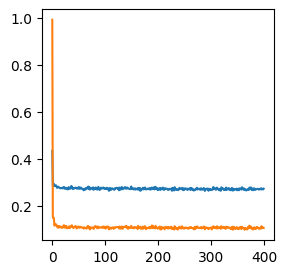

In [13]:
plt.figure(figsize=(3,3))
plt.plot(model.vf_losses)
plt.plot(model.score_losses)

## Train model 

In [14]:
control = np.array([1, 0])
condition = np.array([0, 1])
log_ratio = compute_ratio(model, X, C, 2, condition, control, batch_size=1000)

  0%|          | 0/66 [00:00<?, ?it/s]

In [15]:
adata.obs["log_ratios"] = log_ratio

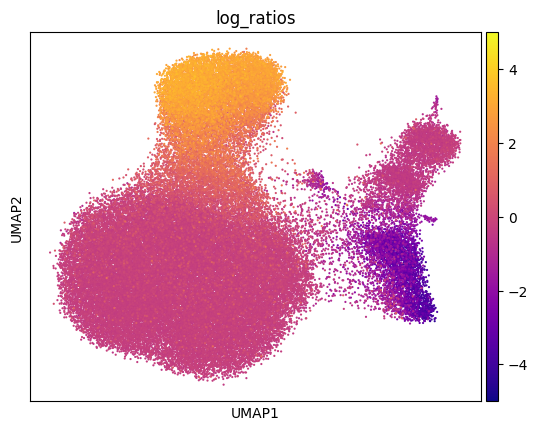

In [16]:
sc.pl.umap(adata, color="log_ratios", s=10, cmap="plasma", vmin=-5, vmax=5)

In [17]:
# sc.pl.umap(adata, color="leiden", s=10)

In [120]:
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)


KeyboardInterrupt



In [ ]:
sc.pl.umap(adata, color="leiden")

In [ ]:
sc.pp.neighbors(adata, n_pcs=40)
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(adata, color="leiden")

In [ ]:
sc.pl.pca_variance_ratio(
    adata,
    log=True,      # optional, helps visualize elbow
    n_pcs=50
)

In [130]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scFM_density_estimation/project_folder/results/abundance_test_experiment/scRatio/deterministic/oversamp_0.05_0.h5ad")

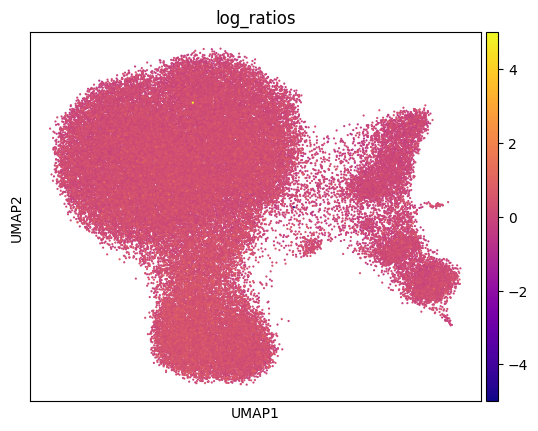

In [131]:
sc.pl.umap(adata, color="log_ratios", s=10, cmap="plasma", vmin=-5, vmax=5)

In [6]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/scFM_density_estimation/project_folder/results/abundance_test_experiment/scRatio_sweep/dimensions_10_batch_size_512_scheduler_type_stochastic_sigma_0.1/oversamp_0.2.h5ad")

In [7]:
adata.obs

,celltype,leiden,treatment,log_ratios_dopri,log_ratios_euler_100,log_ratios_euler_200
AAACATACACCCAA,CD8+ Cytotoxic T,1,1,0.001962,-0.010397,-0.000633
AAACATACCCCTCA,CD8+/CD45RA+ Naive Cytotoxic,0,0,-0.040163,0.011140,0.017366
AAACATACCGGAGA,CD4+/CD45RO+ Memory,0,1,0.023434,0.015141,0.004305
AAACATACTAACCG,CD19+ B,0,0,-0.011999,-0.008873,-0.004066
AAACATACTCTTCA,CD4+/CD25 T Reg,0,0,0.032747,0.016762,0.007649
...,...,...,...,...,...,...
TTTGCATGAGCCTA,CD8+ Cytotoxic T,0,0,-0.035259,-0.018634,-0.020646
TTTGCATGCTAGCA,CD8+/CD45RA+ Naive Cytotoxic,0,0,-0.001483,-0.001820,-0.004296
TTTGCATGCTGCAA,CD8+ Cytotoxic T,1,1,0.022870,0.019740,0.012538
TTTGCATGGCTCCT,CD8+ Cytotoxic T,0,1,0.021812,0.002651,0.019999
